In [3]:
import pandas as pd

df = pd.read_csv('Shopping Trends And Customer Behaviour Dataset.csv')

In [4]:
df.head()

,Unnamed: 0,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,0,1,55,Male,Blouse,Clothing,53,Kentucky,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,1,2,19,Male,Sweater,Clothing,64,Maine,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,2,3,50,Male,Jeans,Clothing,73,Massachusetts,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,3,4,21,Male,Sandals,Footwear,90,Rhode Island,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,4,5,45,Male,Blouse,Clothing,49,Oregon,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              3900 non-null   int64  
 1   Customer ID             3900 non-null   int64  
 2   Age                     3900 non-null   int64  
 3   Gender                  3900 non-null   object 
 4   Item Purchased          3900 non-null   object 
 5   Category                3900 non-null   object 
 6   Purchase Amount (USD)   3900 non-null   int64  
 7   Location                3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [6]:
df.describe(include='all')

,Unnamed: 0,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,NaN,2,25,4,NaN,50,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,NaN,2652,171,1737,NaN,96,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1949.500000,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,3.749949,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,0.716223,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,0.000000,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,974.750000,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1949.500000,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,3.700000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2924.250000,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Color,0
Season,0


In [ ]:
df['Review Rating']=df.groupby('Category')['Review Rating'].transform(lambda x:x.fillna(x.median()))

In [15]:
df.isnull().sum()

,0
unnamed:_0,0
customer_id,0
age,0
gender,0
item_purchased,0
category,0
purchase_amount_(usd),0
location,0
color,0
season,0


In [14]:
df.columns = [col.replace('-_-_-_-_-_-_-_-','').replace('_',' ') for col in df.columns]

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')

df = df.rename(columns={})

In [11]:
df.columns

Index(['Unnamed: 0', 'Customer ID', 'Age', 'Gender', 'Item Purchased',
       'Category', 'Purchase Amount (USD)', 'Location', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [17]:
#create a new column
labels=['Young Adult','Adult','Middle-aged','Senior']
df['age_group']=pd.qcut(df['age'],q=4,labels=labels)

In [18]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [19]:
#create column purchase frequency days
df['purchase_frequency_days'] = df['frequency_of_purchases'].map({
    'Weekly': 7,
    'Bi-Weekly': 14,
    'Monthly': 30,
    'Quarterly': 90,
    'Annually': 365
})

In [20]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,NaN,Fortnightly
1,NaN,Fortnightly
2,7.0,Weekly
3,7.0,Weekly
4,365.0,Annually
5,7.0,Weekly
6,90.0,Quarterly
7,7.0,Weekly
8,365.0,Annually
9,90.0,Quarterly


In [21]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [22]:
(df['discount_applied']==df['promo_code_used']).all()

np.True_

In [23]:
df=df.drop('promo_code_used',axis=1)

In [24]:
df.columns

Index(['unnamed:_0', 'customer_id', 'age', 'gender', 'item_purchased',
       'category', 'purchase_amount_(usd)', 'location', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

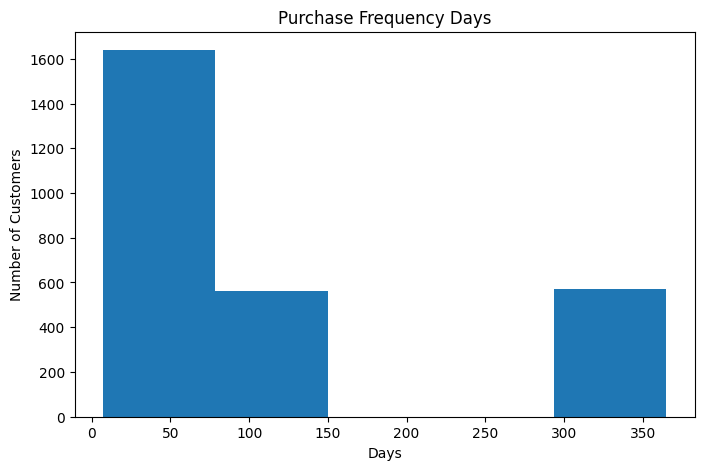

In [25]:
# Histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['purchase_frequency_days'], bins=5)

plt.title('Purchase Frequency Days')
plt.xlabel('Days')
plt.ylabel('Number of Customers')

plt.show()

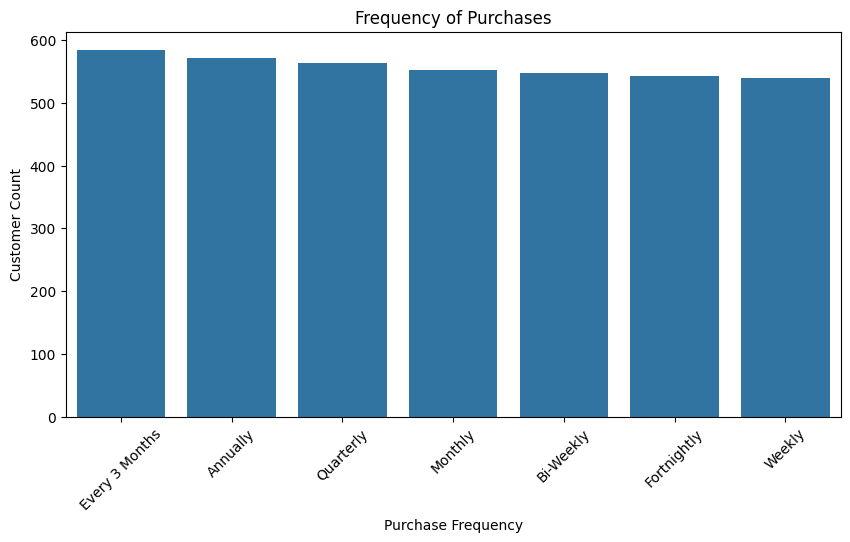

In [28]:
# Purchase Frequency Countplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.countplot(
    x='frequency_of_purchases',
    data=df,
    order=df['frequency_of_purchases'].value_counts().index
)

plt.title('Frequency of Purchases')
plt.xlabel('Purchase Frequency')
plt.ylabel('Customer Count')

plt.xticks(rotation=45)

plt.show()

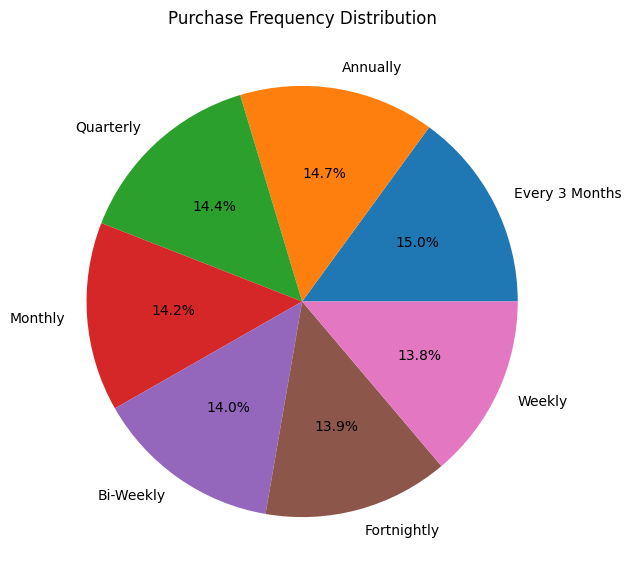

In [29]:
# Import matplotlib for visualization pie cahrt
import matplotlib.pyplot as plt
freq = df['frequency_of_purchases'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    freq.values,
    labels=freq.index,
    autopct='%1.1f%%'
)
plt.title('Purchase Frequency Distribution')
plt.show()

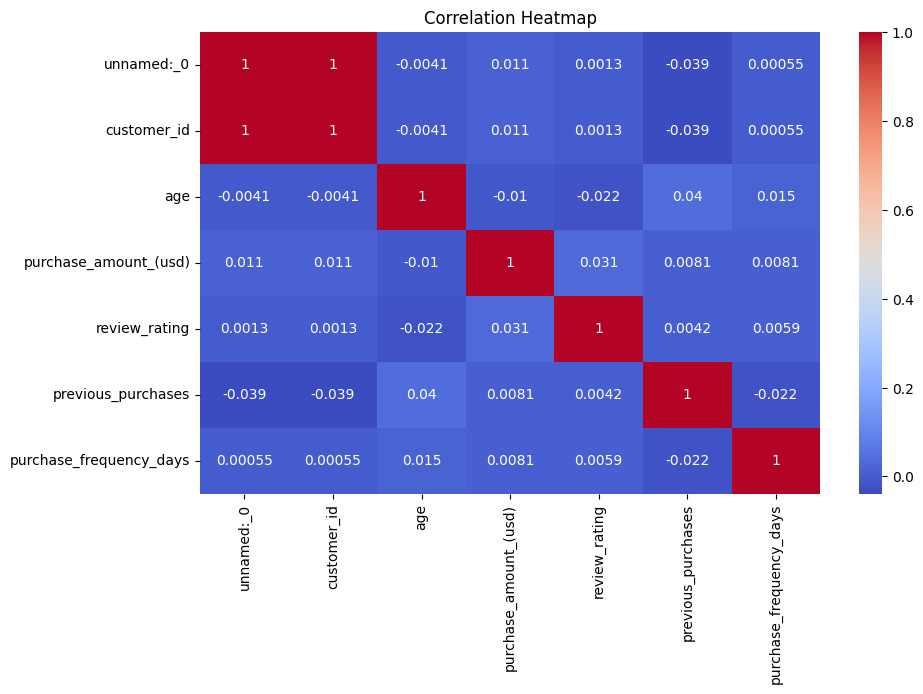

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

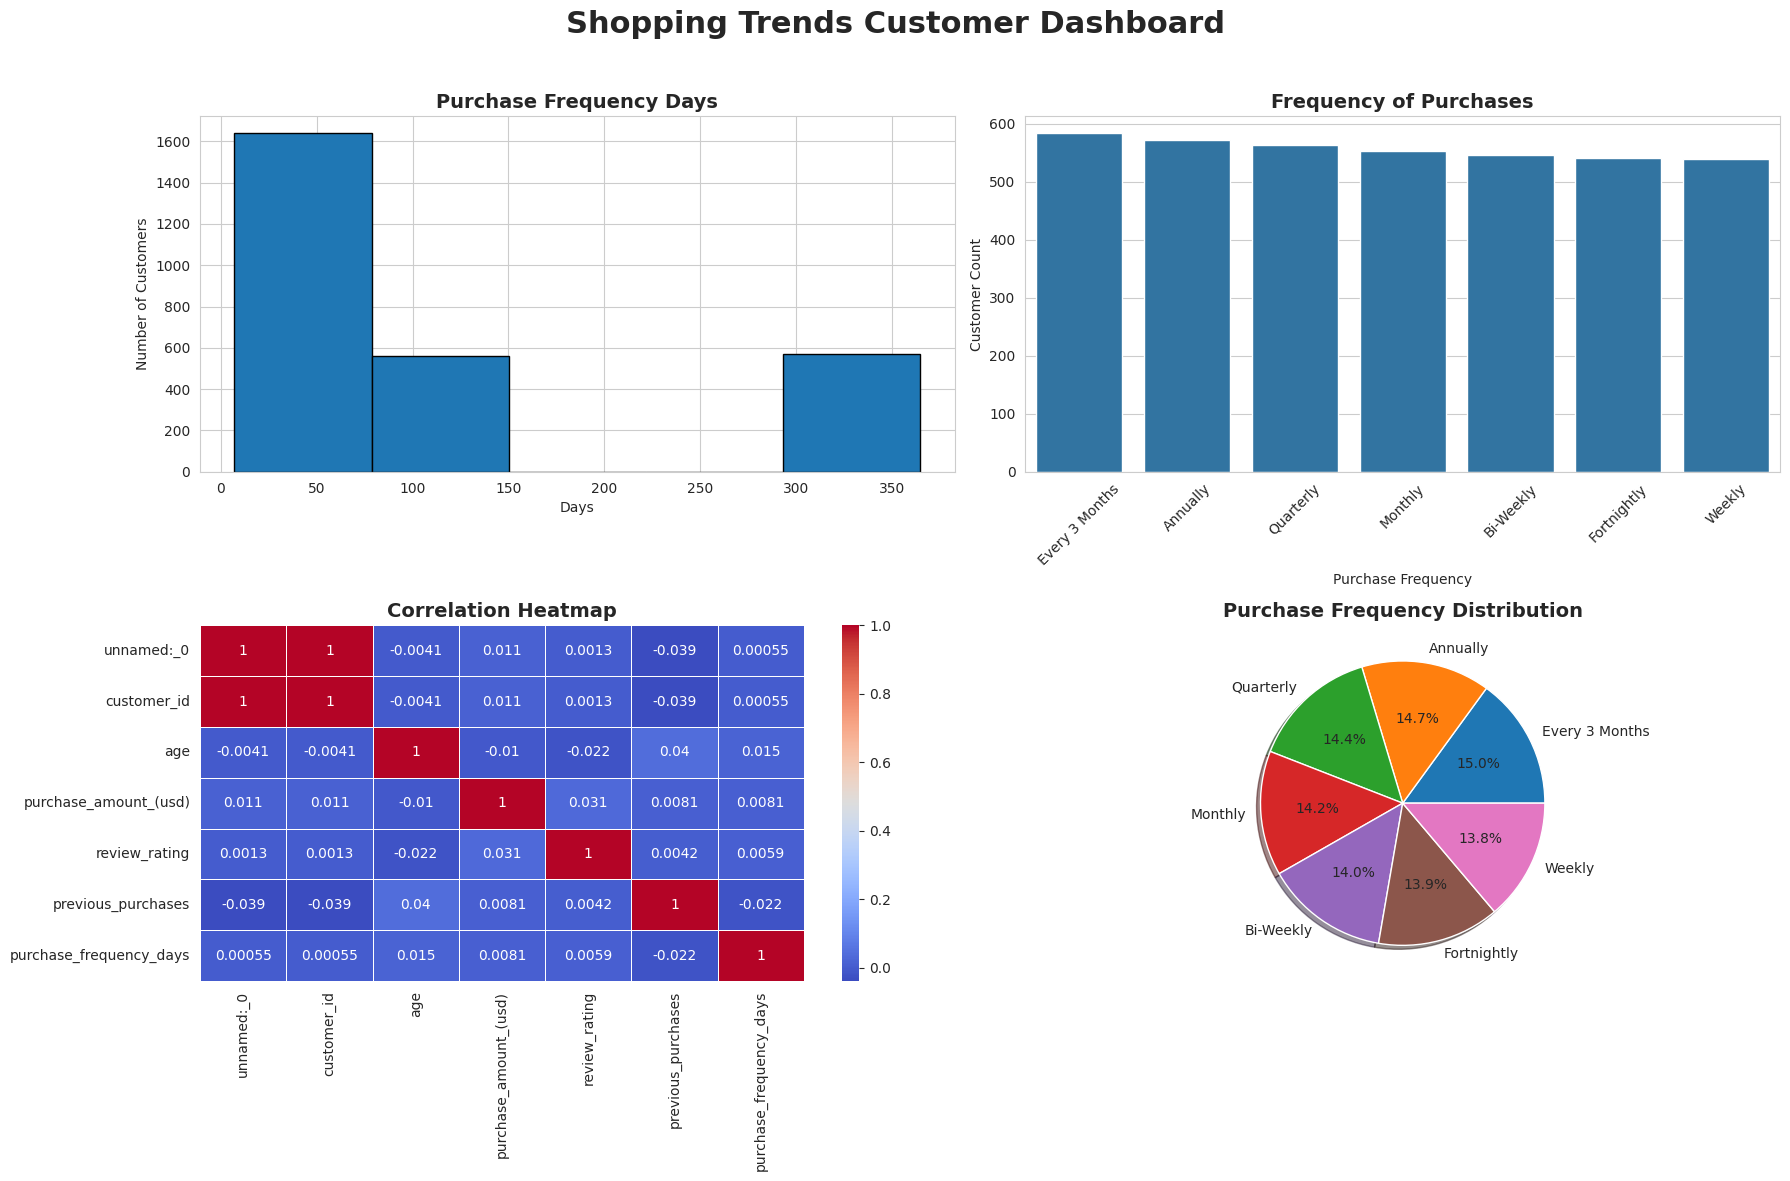

In [32]:
# Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns
# Dashboard style
sns.set_style("whitegrid")
# Create dashboard
fig = plt.figure(figsize=(18,12))

# Main dashboard title
fig.suptitle(
    'Shopping Trends Customer Dashboard',
    fontsize=22,
    fontweight='bold'
)

# ==================================================
# Histogram
# ==================================================

plt.subplot(2,2,1)
plt.hist(
    df['purchase_frequency_days'],
    bins=5,
    edgecolor='black'
)
plt.title(
    'Purchase Frequency Days',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Days')
plt.ylabel('Number of Customers')
# ==================================================
# Countplot
# ==================================================
plt.subplot(2,2,2)
sns.countplot(
    x='frequency_of_purchases',
    data=df,
    order=df['frequency_of_purchases'].value_counts().index
)

plt.title(
    'Frequency of Purchases',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Purchase Frequency')
plt.ylabel('Customer Count')

plt.xticks(rotation=45)
# ==================================================
# Heatmap
# ==================================================
plt.subplot(2,2,3)

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title(
    'Correlation Heatmap',
    fontsize=14,
    fontweight='bold'
)


# ==================================================
# Pie Chart
# ==================================================

plt.subplot(2,2,4)

freq = df['frequency_of_purchases'].value_counts()

plt.pie(
    freq.values,
    labels=freq.index,
    autopct='%1.1f%%',
    shadow=True
)
plt.title(
    'Purchase Frequency Distribution',
    fontsize=14,
    fontweight='bold'
)
# Adjust spacing
plt.tight_layout(rect=[0,0,1,0.96])
# Show dashboard
plt.show()